# Breed Prediction Notebook
Predict cattle/buffalo breed from a single input image using **both** trained models:
- EfficientNet-B2
- ViT-Small

For each model, this notebook displays the input image, the predicted breed class,
and the prediction confidence (%). It also shows Top-5 predictions per model.

In [26]:
import torch
import torch.nn as nn
from torchvision import transforms, models
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path
import timm

# ==================== CONFIG - EDIT THESE PATHS ====================
CODE_DIR = Path(r"D:\B.Tech\CE-AI\Sem 7\MP\Code work")

# Path to the image you want to predict on
IMAGE_PATH = Path(r"C:\Users\Mahipal\Downloads\System workflow (Training).jpg")   # <-- change this

EFFNET_CKPT = CODE_DIR / "best_model_v2_effnetb2.pth"
VIT_CKPT = CODE_DIR / "best_model_v2_vit_small.pth"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]


Using device: cuda


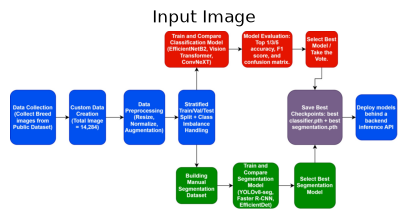

Image path: C:\Users\Mahipal\Downloads\System workflow (Training).jpg
Image size: (3408, 1568)


In [27]:
# ==================== LOAD & DISPLAY INPUT IMAGE ====================
img = Image.open(IMAGE_PATH).convert("RGB")

plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.axis("off")
plt.title("Input Image")
plt.show()

print(f"Image path: {IMAGE_PATH}")
print(f"Image size: {img.size}")


In [28]:
# ==================== LOAD EFFICIENTNET-B2 ====================
eff_checkpoint = torch.load(EFFNET_CKPT, map_location=DEVICE)
eff_classes = eff_checkpoint["classes"]
NUM_CLASSES = len(eff_classes)

effnet_model = models.efficientnet_b2(weights=None)
in_features = effnet_model.classifier[1].in_features
effnet_model.classifier[1] = nn.Linear(in_features, NUM_CLASSES)
effnet_model.load_state_dict(eff_checkpoint["model_state_dict"])
effnet_model = effnet_model.to(DEVICE)
effnet_model.eval()

print(f"EfficientNet-B2 loaded. Val acc at checkpoint: {eff_checkpoint['val_acc']:.4f}")

# EfficientNet-B2 uses 260x260 input
eff_transform = transforms.Compose([
    transforms.Resize((260, 260)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


EfficientNet-B2 loaded. Val acc at checkpoint: 0.8110


In [29]:
# ==================== LOAD VIT-SMALL ====================
vit_checkpoint = torch.load(VIT_CKPT, map_location=DEVICE)
vit_classes = vit_checkpoint["classes"]

vit_model = timm.create_model("vit_small_patch16_224", pretrained=False, num_classes=len(vit_classes))
vit_model.load_state_dict(vit_checkpoint["model_state_dict"])
vit_model = vit_model.to(DEVICE)
vit_model.eval()

print(f"ViT-Small loaded. Val acc at checkpoint: {vit_checkpoint['val_acc']:.4f}")

# ViT-Small uses 224x224 input
vit_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


ViT-Small loaded. Val acc at checkpoint: 0.7986


In [30]:
# ==================== PREDICTION FUNCTION ====================
def predict(model, transform, classes, image, device, top_k=5):
    # \"\"\"Returns list of (class_name, confidence_percent) tuples, sorted descending.\"\"\"
    input_tensor = transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        outputs = model(input_tensor)
        probs = torch.softmax(outputs, dim=1)[0]
    top_probs, top_idxs = torch.topk(probs, top_k)
    results = [(classes[idx.item()], prob.item() * 100) for prob, idx in zip(top_probs, top_idxs)]
    return results

import numpy as np

def predict_with_rejection(model, transform, classes, image, device, 
                             confidence_threshold=40.0, entropy_threshold=0.9, top_k=5):
    """
    Returns (is_known, results, entropy_value)
    is_known: False if image is likely NOT a cattle/buffalo breed
    results: list of (class_name, confidence_percent) tuples
    entropy_value: computed entropy of the prediction distribution
    """
    input_tensor = transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        outputs = model(input_tensor)
        probs = torch.softmax(outputs, dim=1)[0]

    # ---- Entropy calculation ----
    probs_np = probs.cpu().numpy()
    entropy = -np.sum(probs_np * np.log(probs_np + 1e-12))  # small epsilon avoids log(0)

    # ---- Top-k results ----
    top_probs, top_idxs = torch.topk(probs, top_k)
    results = [(classes[idx.item()], prob.item() * 100) for prob, idx in zip(top_probs, top_idxs)]

    top1_confidence = results[0][1]

    # ---- Decision: is this a known class? ----
    is_known = (top1_confidence >= confidence_threshold) and (entropy <= entropy_threshold)

    return is_known, results, entropy


In [31]:
# ==================== RUN PREDICTIONS ====================
eff_results = predict(effnet_model, eff_transform, eff_classes, img, DEVICE, top_k=5)
vit_results = predict(vit_model, vit_transform, vit_classes, img, DEVICE, top_k=5)

print("=" * 55)
print("EfficientNet-B2 Predictions (Top-5)")
print("=" * 55)
for rank, (cls, conf) in enumerate(eff_results, 1):
    print(f"{rank}. {cls:<30} {conf:6.2f}%")

print()
print("=" * 55)
print("ViT-Small Predictions (Top-5)")
print("=" * 55)
for rank, (cls, conf) in enumerate(vit_results, 1):
    print(f"{rank}. {cls:<30} {conf:6.2f}%")


EfficientNet-B2 Predictions (Top-5)
1. cattle_khillar                  49.82%
2. buffalo_nagpuri                 12.02%
3. cattle_vechur                   11.71%
4. cattle_malnad_gidda              4.51%
5. cattle_hallikar                  4.06%

ViT-Small Predictions (Top-5)
1. cattle_punganur                 30.57%
2. cattle_pulikulam                23.37%
3. cattle_kosali                   12.99%
4. cattle_konkan_kapila             5.26%
5. cattle_kangayam                  5.24%


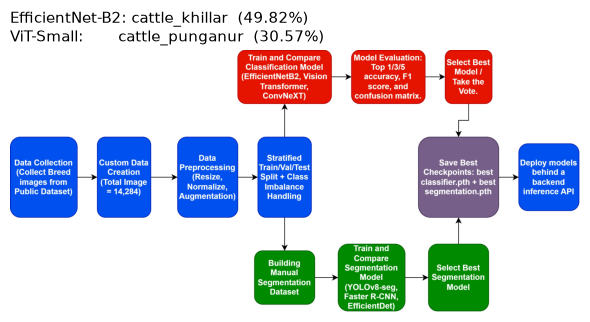


Final Prediction Summary
-------------------------------------------------------
Model               Predicted Breed          Confidence
-------------------------------------------------------
EfficientNet-B2     cattle_khillar               49.82%
ViT-Small           cattle_punganur              30.57%


In [32]:
# ==================== FINAL VISUAL SUMMARY ====================
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.imshow(img)
ax.axis("off")

eff_top_class, eff_top_conf = eff_results[0]
vit_top_class, vit_top_conf = vit_results[0]

title = (
    f"EfficientNet-B2: {eff_top_class}  ({eff_top_conf:.2f}%)\n"
    f"ViT-Small:       {vit_top_class}  ({vit_top_conf:.2f}%)"
)
ax.set_title(title, fontsize=11, loc="left")
plt.tight_layout()
plt.show()

print("\nFinal Prediction Summary")
print("-" * 55)
print(f"{'Model':<20}{'Predicted Breed':<25}{'Confidence':>10}")
print("-" * 55)
print(f"{'EfficientNet-B2':<20}{eff_top_class:<25}{eff_top_conf:>9.2f}%")
print(f"{'ViT-Small':<20}{vit_top_class:<25}{vit_top_conf:>9.2f}%")


In [33]:
# ---- Diagnostic: check typical confidence & entropy on a KNOWN correct image ----
is_known, results, entropy_val = predict_with_rejection(
    effnet_model, eff_transform, eff_classes, img, DEVICE
)

print(f"Top-1 prediction: {results[0][0]} ({results[0][1]:.2f}%)")
print(f"Entropy: {entropy_val:.4f}")
print(f"Classified as known: {is_known}")

Top-1 prediction: cattle_khillar (49.82%)
Entropy: 2.0198
Classified as known: False


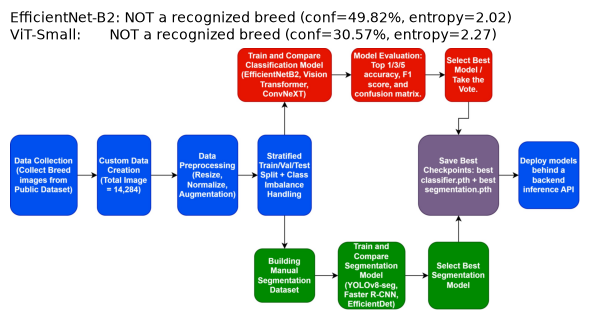


Final Prediction Summary
-----------------------------------------------------------------
Model             Result                                       
-----------------------------------------------------------------
EfficientNet-B2   NOT a recognized breed (conf=49.82%, entropy=2.02)
ViT-Small               NOT a recognized breed (conf=30.57%, entropy=2.27)


In [34]:
# ==================== FINAL VISUAL SUMMARY (with rejection handling) ====================
eff_is_known, eff_results, eff_entropy = predict_with_rejection(
    effnet_model, eff_transform, eff_classes, img, DEVICE
)
vit_is_known, vit_results, vit_entropy = predict_with_rejection(
    vit_model, vit_transform, vit_classes, img, DEVICE
)

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.imshow(img)
ax.axis("off")

if eff_is_known:
    eff_line = f"EfficientNet-B2: {eff_results[0][0]}  ({eff_results[0][1]:.2f}%)"
else:
    eff_line = f"EfficientNet-B2: NOT a recognized breed (conf={eff_results[0][1]:.2f}%, entropy={eff_entropy:.2f})"

if vit_is_known:
    vit_line = f"ViT-Small:       {vit_results[0][0]}  ({vit_results[0][1]:.2f}%)"
else:
    vit_line = f"ViT-Small:       NOT a recognized breed (conf={vit_results[0][1]:.2f}%, entropy={vit_entropy:.2f})"

ax.set_title(eff_line + "\n" + vit_line, fontsize=10, loc="left")
plt.tight_layout()
plt.show()

print("\nFinal Prediction Summary")
print("-" * 65)
print(f"{'Model':<18}{'Result':<45}")
print("-" * 65)
print(f"{'EfficientNet-B2':<18}{eff_line.split(': ', 1)[1]}")
print(f"{'ViT-Small':<18}{vit_line.split(': ', 1)[1]}")